Matrix #   Size        Naive Time    NumPy Time
1         3x3     0.0026819761842489243     4.346296191215515e-05
2         6x6     4.733353853225708e-05     6.582587957382202e-06
3         12x12     0.00023649632930755615     5.755573511123657e-06
4         24x24     0.0021443311125040054     5.0613656640052795e-05
5         48x48     0.013010341674089432     7.452629506587982e-05
6         96x96     0.10044868662953377     0.0002686120569705963
7         192x192     0.8309441599994898     0.0022544823586940765
8         384x384     7.838145995512605     0.0032621491700410843


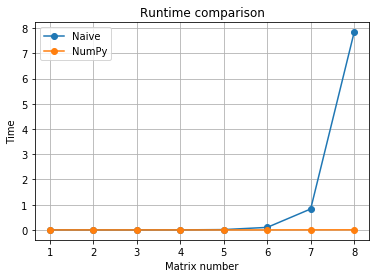

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import time

# naive matrix multiply
def naive_matrix_multiplication(A, B):
    n = len(A)
    
    # make empty result matrix
    C = []
    for i in range(n):
        row = [0] * n
        C.append(row)

    # multiply
    for i in range(n):
        for j in range(n):
            total = 0
            for k in range(n):
                total = total + A[i][k] * B[k][j]
            C[i][j] = total

    return C


# sizes: 3, 6, 12, ...
sizes = []
current = 3
for i in range(8):
    sizes.append(current)
    current = current * 2


naive_times = []
numpy_times = []

matrix_numbers = []
for i in range(8):
    matrix_numbers.append(i+1)


# run tests
for n in sizes:
    
    # random matrices
    A = np.random.rand(n, n)
    B = np.random.rand(n, n)

    # convert to lists
    A_list = A.tolist()
    B_list = B.tolist()

    # naive timing
    start = time.perf_counter()
    C1 = naive_matrix_multiplication(A_list, B_list)
    end = time.perf_counter()
    t1 = end - start
    naive_times.append(t1)

    # numpy timing
    start = time.perf_counter()
    C2 = np.matmul(A, B)
    end = time.perf_counter()
    t2 = end - start
    numpy_times.append(t2)


# print results
print("Matrix #   Size        Naive Time    NumPy Time")
for i in range(len(sizes)):
    print(i+1, "       ", str(sizes[i]) + "x" + str(sizes[i]), 
          "   ", naive_times[i], "   ", numpy_times[i])


# plot
plt.plot(matrix_numbers, naive_times, marker='o', label='Naive')
plt.plot(matrix_numbers, numpy_times, marker='o', label='NumPy')

plt.title("Runtime comparison")
plt.xlabel("Matrix number")
plt.ylabel("Time")

plt.legend()
plt.grid()

plt.show()